📌 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

📌 Load Dataset

In [2]:
df = pd.read_csv("data/advertising.csv")
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


📌 Basic Information

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


📌 Check Missing Values

In [4]:
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

📌 Correlation Matrix

In [5]:
print(df.corr())

            Unnamed: 0        TV     Radio  Newspaper     Sales
Unnamed: 0    1.000000  0.017715 -0.110680  -0.154944 -0.051616
TV            0.017715  1.000000  0.054809   0.056648  0.782224
Radio        -0.110680  0.054809  1.000000   0.354104  0.576223
Newspaper    -0.154944  0.056648  0.354104   1.000000  0.228299
Sales        -0.051616  0.782224  0.576223   0.228299  1.000000


📌 Correlation with Sales

In [6]:
print(df.corr()["Sales"])

Unnamed: 0   -0.051616
TV            0.782224
Radio         0.576223
Newspaper     0.228299
Sales         1.000000
Name: Sales, dtype: float64


📌 Heatmap Visualization

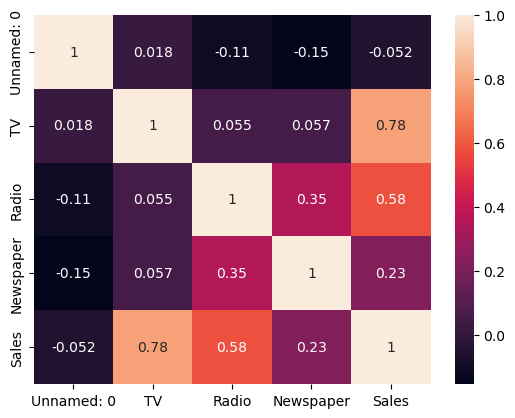

In [7]:
sns.heatmap(df.corr(), annot=True)
plt.show()

📌 Scatter Plot (TV vs Sales and Radio vs Sales)

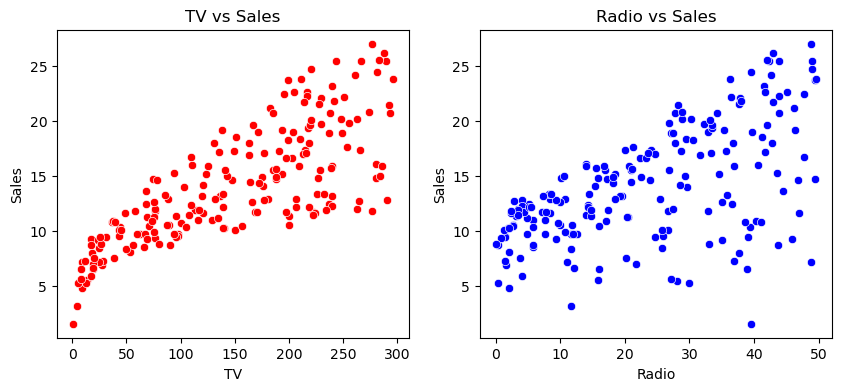

In [27]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.scatterplot(x="TV", y="Sales", data=df, color= "red")
plt.title("TV vs Sales")

plt.subplot(1,2,2)
sns.scatterplot(x="Radio", y="Sales", data=df ,color= "blue")
plt.title("Radio vs Sales")

plt.show()

📌 Define Features and Target

In [10]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

📌 Train-Test Split

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

📌 Train Model

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

📌 Prediction

In [13]:
y_pred = model.predict(X_test)

📌 Model Evaluation

In [14]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 3.1740973539761015
R2 Score: 0.8994380241009121


📌 Actual vs Predicted Visualization

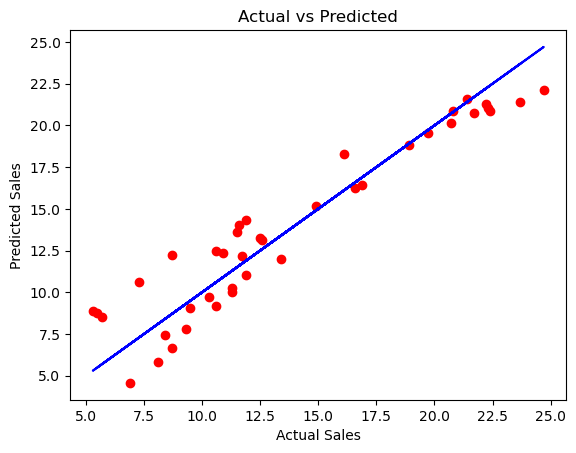

In [29]:
plt.scatter(y_test, y_pred, color="red")
plt.plot(y_test, y_test, color="blue")

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")
plt.show()

📌 Try Custom Prediction

In [21]:
prediction = model.predict(pd.DataFrame([[200, 40, 50]], columns=X.columns))
print( "the predicted sales is " ,prediction[0])

the predicted sales is  19.63082871830931
